In [2]:
import math
import matplotlib.pyplot as plt

def calc_dg_from_nm(kd_nm: float, temp_celsius: float = 25.0) -> float:
    """
    Calculates the change in Gibbs free energy (ΔG) in kcal/mol
    from a dissociation constant (Kd) provided in nanomolar (nM).

    Parameters:
    kd_nm (float): Dissociation constant in nanomolar (nM).
    temp_celsius (float): Temperature in degrees Celsius. Defaults to 25.0.

    Returns:
    float: ΔG in kcal/mol.
    """
    # Ideal gas constant in kcal/(K*mol)
    R = 0.001987204

    # Convert temperature to Kelvin
    T = temp_celsius + 273.15

    # Convert Kd from nM to Molar (M)
    kd_molar = kd_nm * 1e-9

    # Calculate ΔG = RT ln(Kd)
    delta_g = R * T * math.log(kd_molar)

    return delta_g



print(calc_dg_from_nm(1000) * 4.184)


-34.248052557720115


These are PDBind examples. They could have been in the training data

Text(0.5, 0, 'KJ/mol experimental')

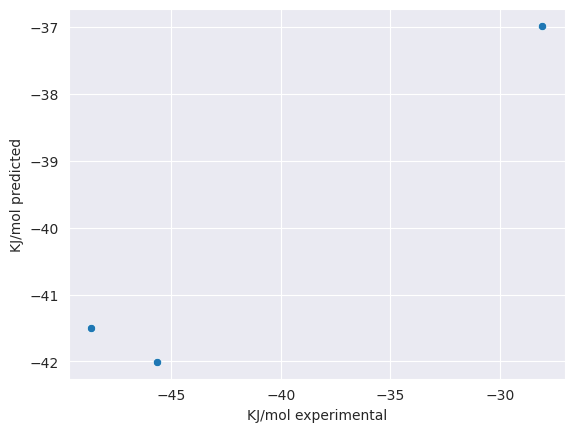

In [3]:
experimental = [6.71, 11.63, 10.91]
prediction = [8.84, 9.92, 10.04]

experimental_kj = map( lambda x: x * -4.184, experimental)
prediction_kj = map( lambda x: x * -4.184, prediction)
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x = experimental_kj, y = prediction_kj)
plt.ylabel("KJ/mol predicted")
plt.xlabel("KJ/mol experimental")

 ss These examples are mostly not in the training data. Exception being

exception being Mlc-1 peptides

In [4]:


bcl_xl_affinities = [-10.302607, -10.01573,  -9.94187,  -9.765704,  -10.090412, -10.014381,  -9.921239, -9.8090515, -9.996739,  -9.8242235,  -9.677007]
mcl1_affinities = [ -10.336679,  -10.048344,  -9.971469,  -9.825713, -10.126925,  -10.10933,  -9.969996, -9.903861, -10.091563, -9.90845,  -9.825992]



bcl_xl_affinities_kj = list(map( lambda x: x * 4.184, bcl_xl_affinities))
mcl1_affinities_kj = list(map( lambda x: x * 4.184, mcl1_affinities))

In [24]:
#This is based on yeast display

bcl_xl_kd = [9, 1000, 1000, 1000, 1000, 1000, 23, 33, 26, 19, 55]
mcl_1_kd = [6, 20, 7, 9, 11, 21, 1000, 1000, 1000, 1000, 1000]

# This is based on a better assay

bcl_xl_kd = [1.3,10000,10000,10000,10000,10000,2.9,9,13,6,19]
mcl_1_kd = [1.9,4,20,30,192,273,10000,10000,10000,10000,10000]
bcl_w_kd = [2.1, 10000,10000,10000,10000,10000, 81, 40, 220, 30, 109]
blc_2_kd = [1.4 , 10000,10000,10000,10000,10000, 73, 132, 255, 137, 725]


11

In [32]:
kd_matrix = [
    [48, 0.65, 2.2, 10000, 0.27, 8.3, 11, 102],       # Bcl-xL
    [122, 61, 6.0, 10000, 57, 8.5, 145, 10000],       # Bcl-2
    [87, 2.1, 9.2, 18, 10000, 340, 50, 1100],         # Mcl-1
    [34, 2.2, 2.4, 10000, 12, 1.7, 53, 73],           # Bcl-w
    [2.4, 0.17, 3.2, 70, 1100, 202, 13, 243]          # Bfl-1
]


delta_g_matrix = []
for row in kd_matrix:
    delta_g_row = list(map(lambda x: x * 4.184, map(calc_dg_from_nm, row)))
    delta_g_matrix.append(delta_g_row)

delta_g_matrix

[[-41.775539126605935,
  -52.439971035670666,
  -49.41752717495446,
  -28.5400437981001,
  -54.61785945179805,
  -46.12597303452269,
  -45.42780026749282,
  -39.90697146158888],
 [-39.46311864736938,
  -41.18140049952776,
  -46.93038468308107,
  -28.5400437981001,
  -41.349529779605064,
  -46.066947467246365,
  -39.03497134706052,
  -28.5400437981001],
 [-40.301285953181434,
  -49.53284827972038,
  -45.87076947567661,
  -44.20697238174034,
  -28.5400437981001,
  -36.92237500330959,
  -41.67434316949852,
  -34.011782748252784],
 [-42.630383762929604,
  -49.41752717495446,
  -49.201829738384326,
  -28.5400437981001,
  -45.21210283092269,
  -50.05667437470801,
  -41.529897068897455,
  -40.73621562901239],
 [-49.201829738384326,
  -55.764683134328024,
  -48.48867833540829,
  -40.84024306182107,
  -34.011782748252784,
  -38.21311302577685,
  -45.01368042389227,
  -37.755017329876544]]

In [25]:
bcl_xl_kj_true  = list(map(lambda x: x * 4.184, map(calc_dg_from_nm, bcl_xl_kd)))
mcl1_kj_true  = list(map(lambda x: x * 4.184, map(calc_dg_from_nm, mcl_1_kd)))
bcl_w_true = list(map(lambda x: x * 4.184, map(calc_dg_from_nm, bcl_w_kd)))
bcl_2_true = list(map(lambda x: x * 4.184, map(calc_dg_from_nm, blc_2_kd)))

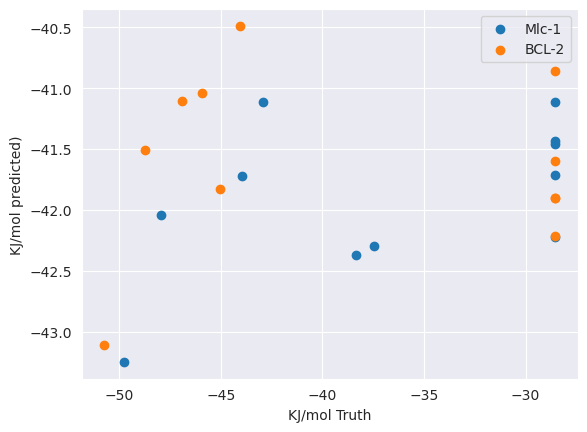

In [21]:
plt.scatter(mcl1_kj_true, mcl1_affinities_kj)
plt.scatter(bcl_xl_kj_true, bcl_xl_affinities_kj)
plt.ylabel ("KJ/mol predicted"")")
plt.xlabel("KJ/mol Truth")
plt.legend(["Mlc-1", "BCL-2"])

In [28]:
bcl_2_true

[-50.53797872890273,
 -28.5400437981001,
 -28.5400437981001,
 -28.5400437981001,
 -28.5400437981001,
 -28.5400437981001,
 -40.73621562901239,
 -39.26782426183533,
 -37.63552640628563,
 -39.17565912239116,
 -35.04524443959888]

In [8]:

import numpy as np
np.corrcoef(mcl1_kj_true, mcl1_affinities_kj)

array([[1.        , 0.45590651],
       [0.45590651, 1.        ]])